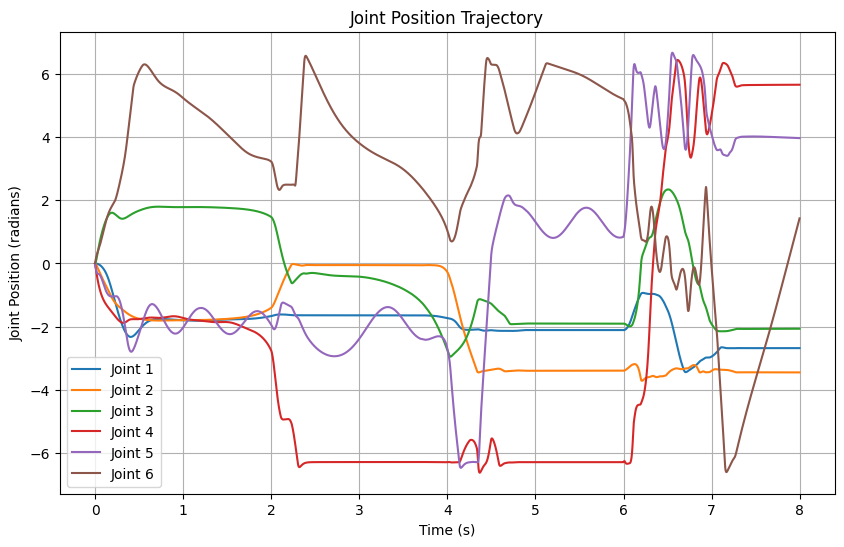

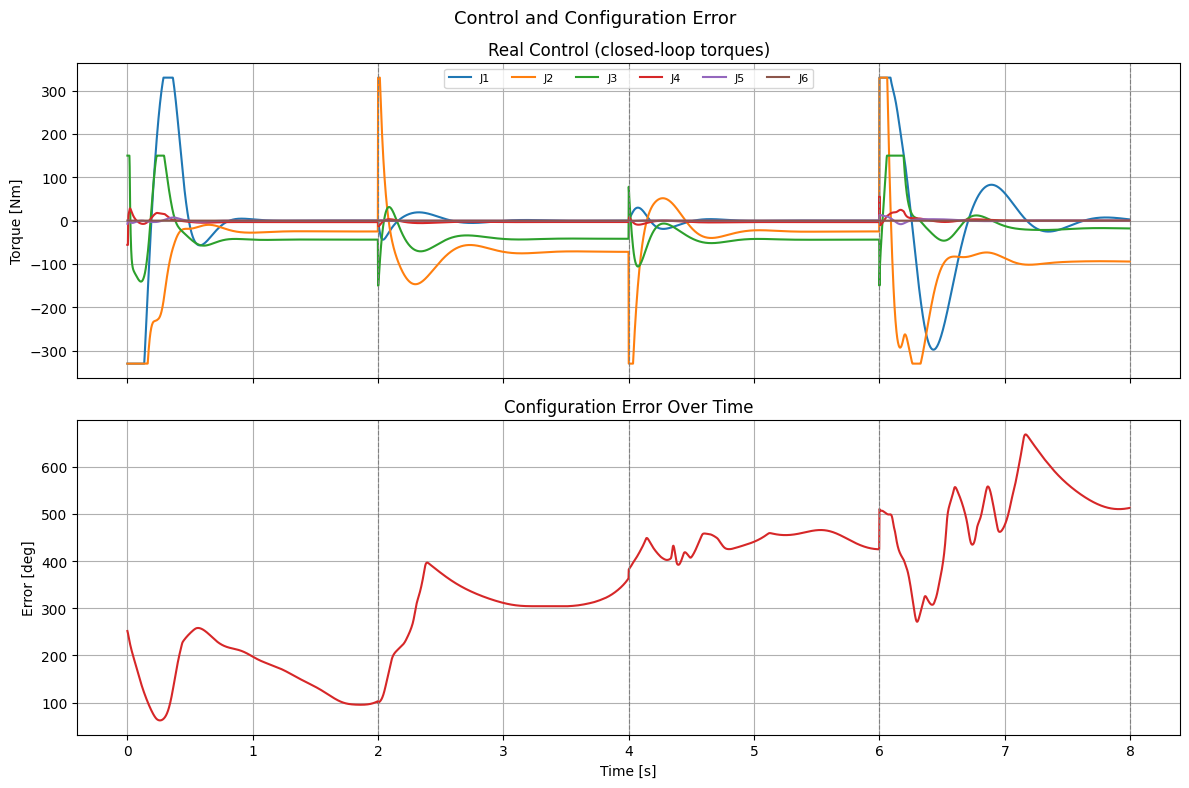

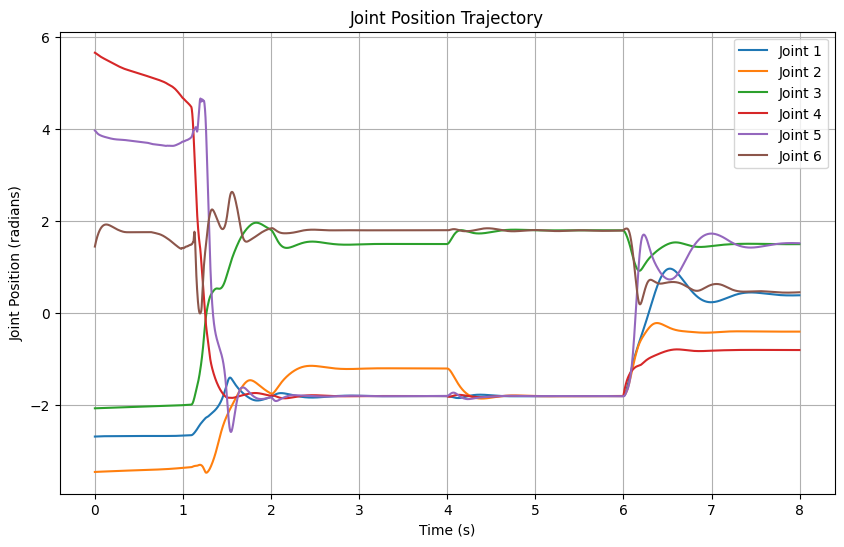

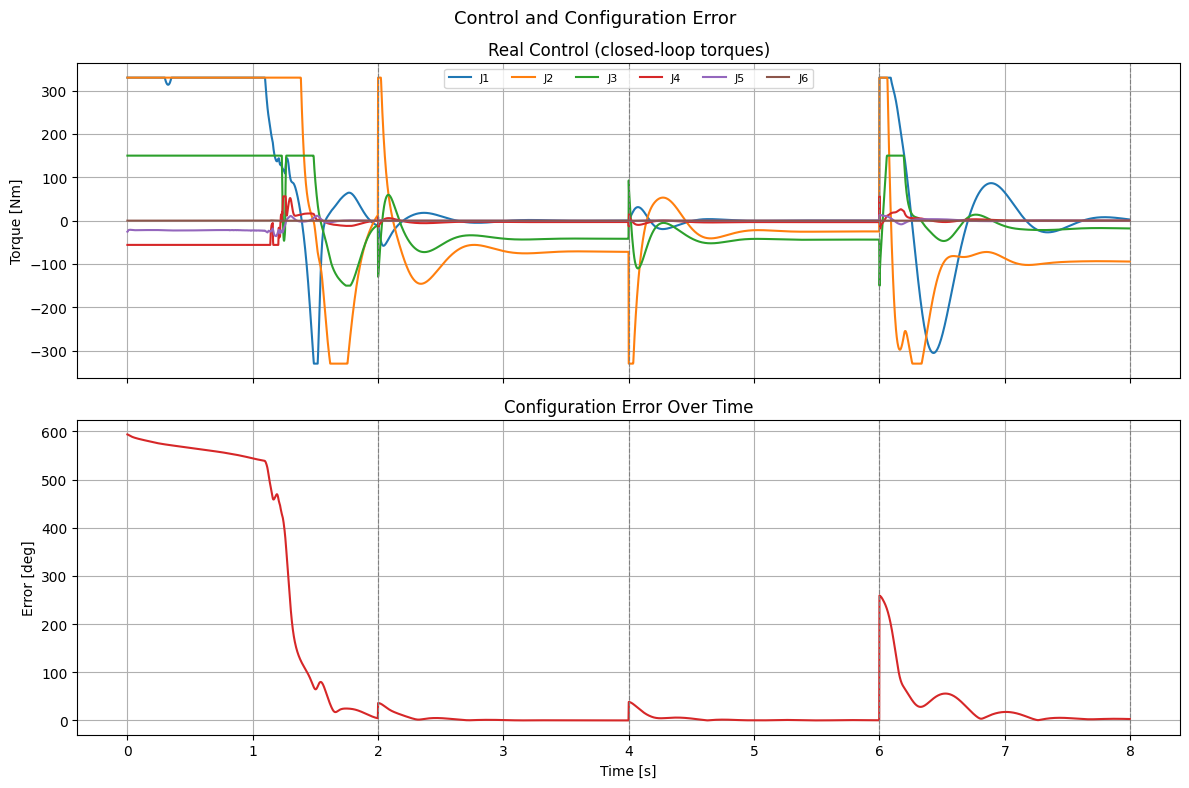

Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.3582     64.4%     98.9%   56.9445
  2            0.2770     62.9%    105.2%   85.6049
  3            0.3249     64.1%    104.4%   37.7621
  4            0.0491     23.2%     99.0%    9.6554
  5            0.1923     19.0%     98.3%    3.7690
  6            0.2622     34.5%     96.9%    0.0169
Global FF coverage: 63.3%   FB correction: 102.8%
Global correlation FF↔tot: 0.2967


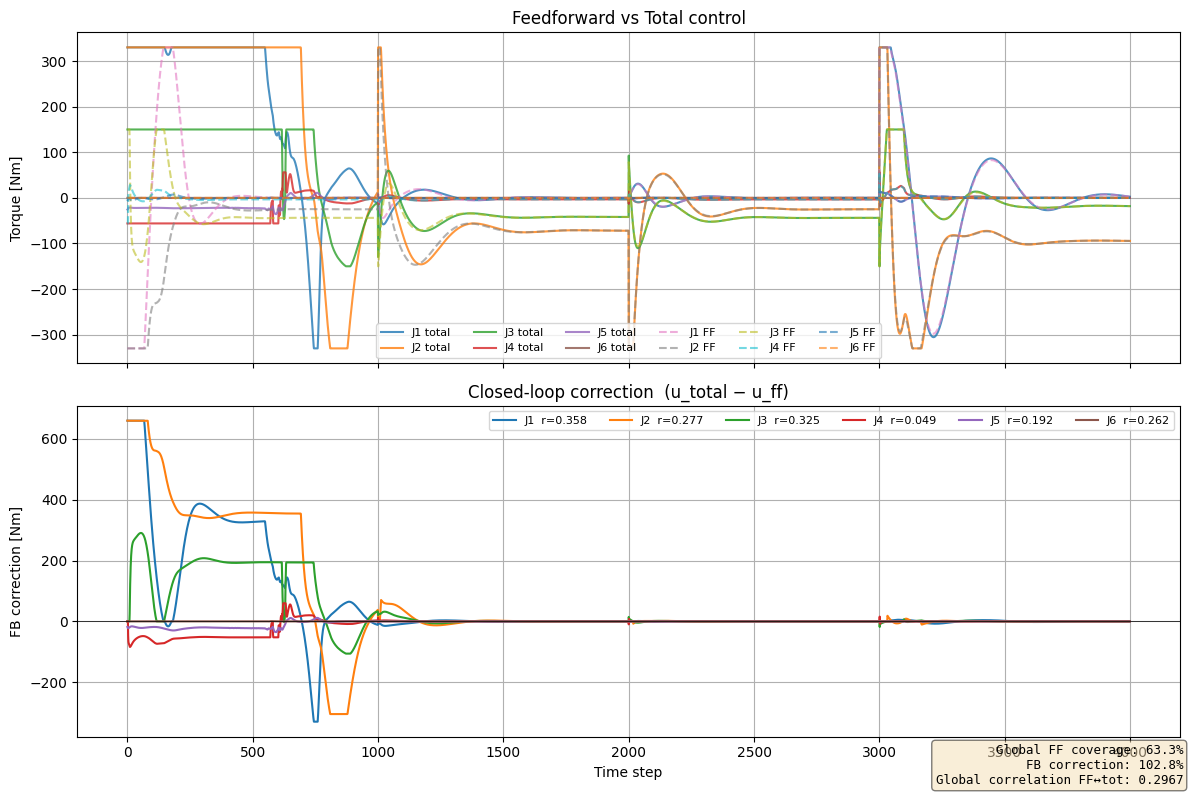

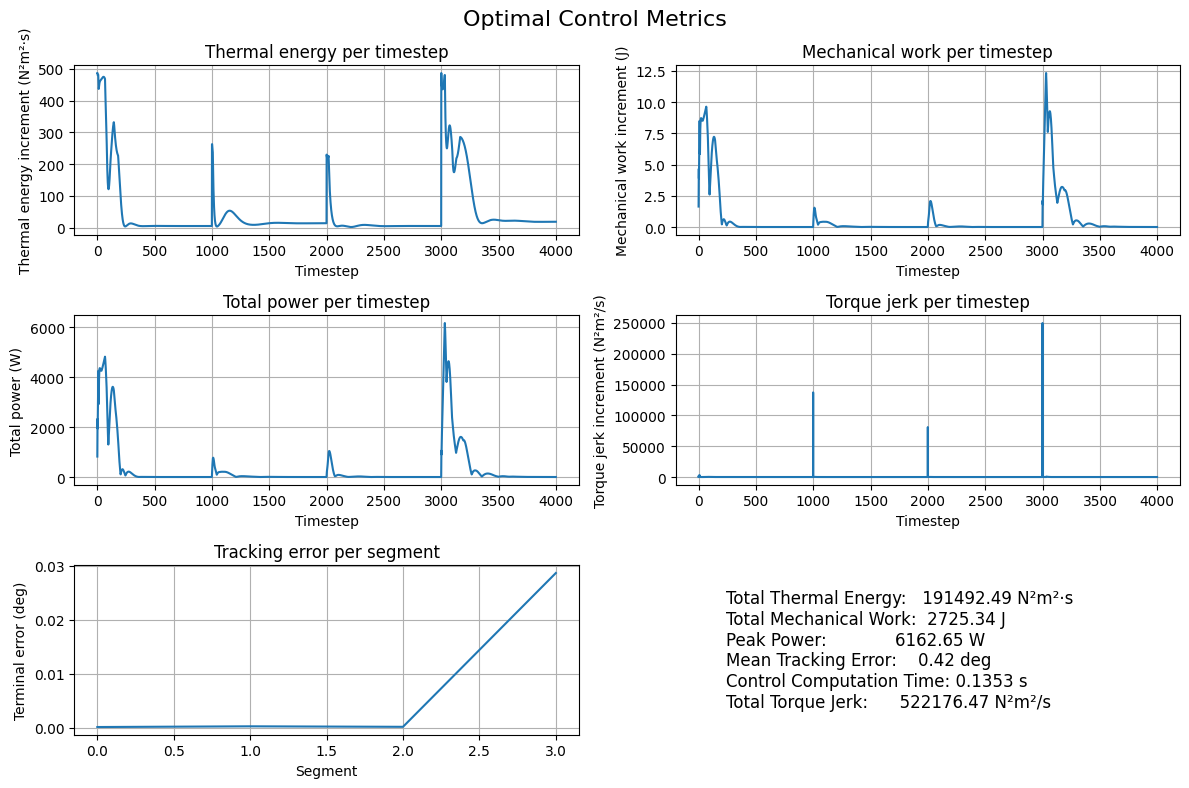

In [4]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox, Trajectories
import optimal.metrics as metrics
import numpy as np
import time

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof

controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start_time = time.time()
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                            x_goal=target, 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]
end_time = time.time()
controller_time = end_time - start_time

xs_real, us_real = robot_mj_model.simulate_control(us=us)
robot_mj_model.plot_position(xs_real, DT)
metrics.plot_controls_and_error(us_real, xs_real, DT, path[1:], [1000]*(len(path)))

xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.plot_position(xs_real, DT)
metrics.plot_controls_and_error(us_real, xs_real, DT, path[1:], [1000]*(len(path)))
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us, xs, DT, path[1:], [1000]*(len(path)-1), controller_time)

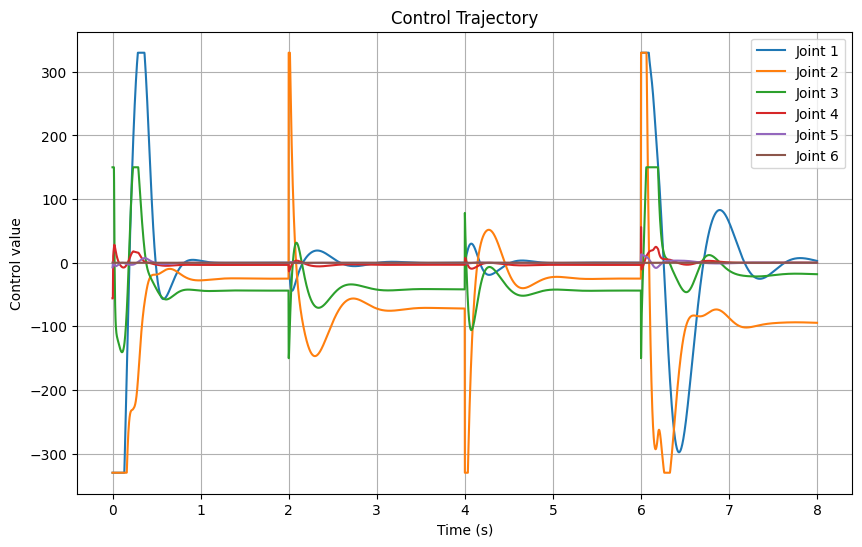

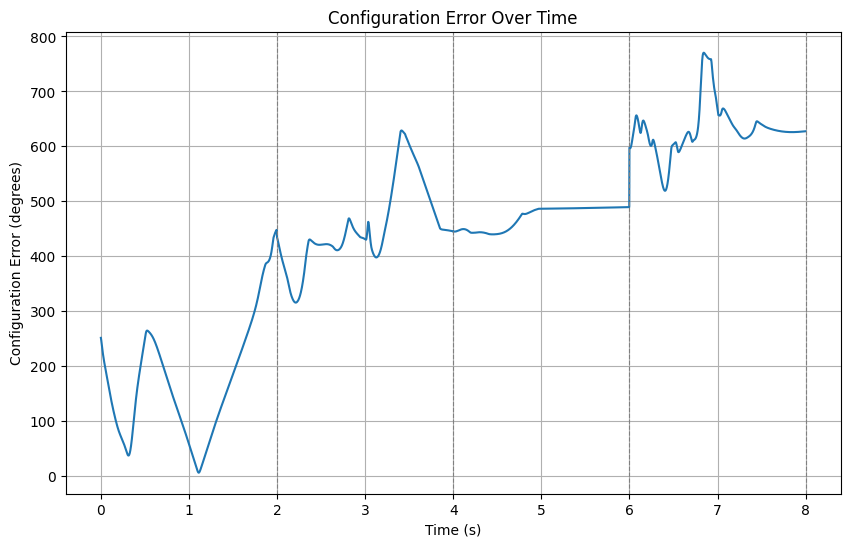

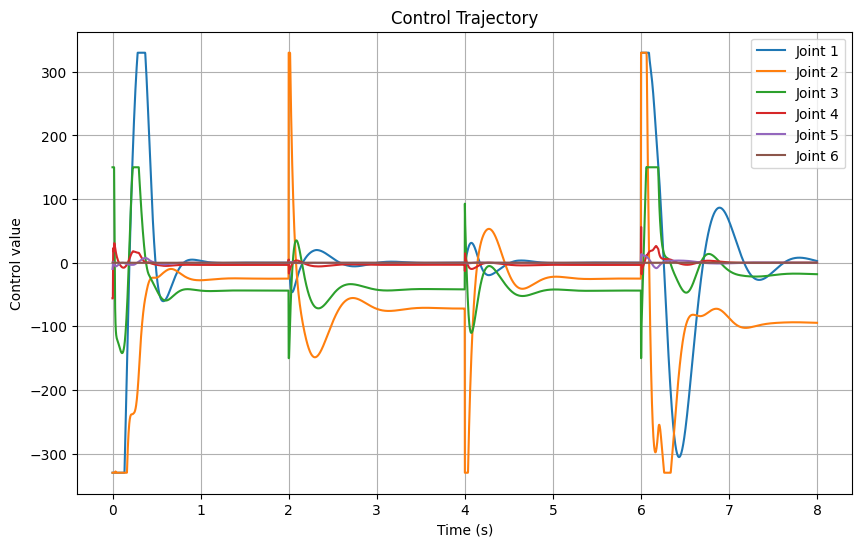

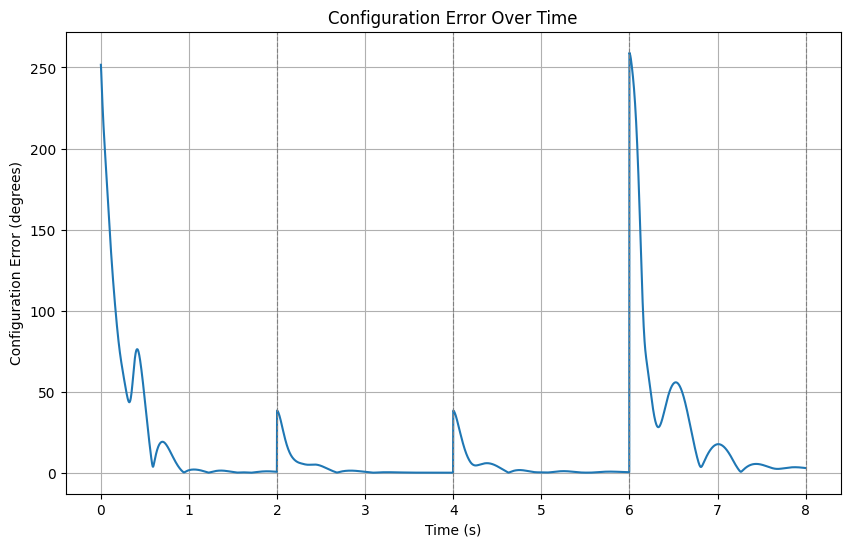

In [14]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

